In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('owid-covid-data.csv')
df.head()

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
0,AFG,Asia,Afghanistan,2020-01-03,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
1,AFG,Asia,Afghanistan,2020-01-04,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
2,AFG,Asia,Afghanistan,2020-01-05,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
3,AFG,Asia,Afghanistan,2020-01-06,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
4,AFG,Asia,Afghanistan,2020-01-07,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN


In [3]:
df.shape

(350085, 67)

In [4]:
df.dtypes

iso_code                                    object
continent                                   object
location                                    object
date                                        object
total_cases                                float64
                                            ...   
population                                 float64
excess_mortality_cumulative_absolute       float64
excess_mortality_cumulative                float64
excess_mortality                           float64
excess_mortality_cumulative_per_million    float64
Length: 67, dtype: object

In [5]:
df['date'] = pd.to_datetime(df['date'])
df.dtypes

iso_code                                           object
continent                                          object
location                                           object
date                                       datetime64[ns]
total_cases                                       float64
                                                ...      
population                                        float64
excess_mortality_cumulative_absolute              float64
excess_mortality_cumulative                       float64
excess_mortality                                  float64
excess_mortality_cumulative_per_million           float64
Length: 67, dtype: object

In [6]:
df.isnull().sum()

iso_code                                        0
continent                                   16665
location                                        0
date                                            0
total_cases                                 37997
                                            ...  
population                                      0
excess_mortality_cumulative_absolute       337901
excess_mortality_cumulative                337901
excess_mortality                           337901
excess_mortality_cumulative_per_million    337901
Length: 67, dtype: int64

In [7]:
df.shape

(350085, 67)

In [8]:
df['continent'].notna()
df['total_cases'] = df['total_cases'].fillna(0)
df['total_deaths'] = df['total_deaths'].fillna(0)
df['new_cases'] = df['new_cases'].fillna(0)
df['new_deaths'] = df['new_deaths'].fillna(0)
df['total_vaccinations'] = df['total_vaccinations'].fillna(0)

In [9]:
df = df[df['continent'].notna()]

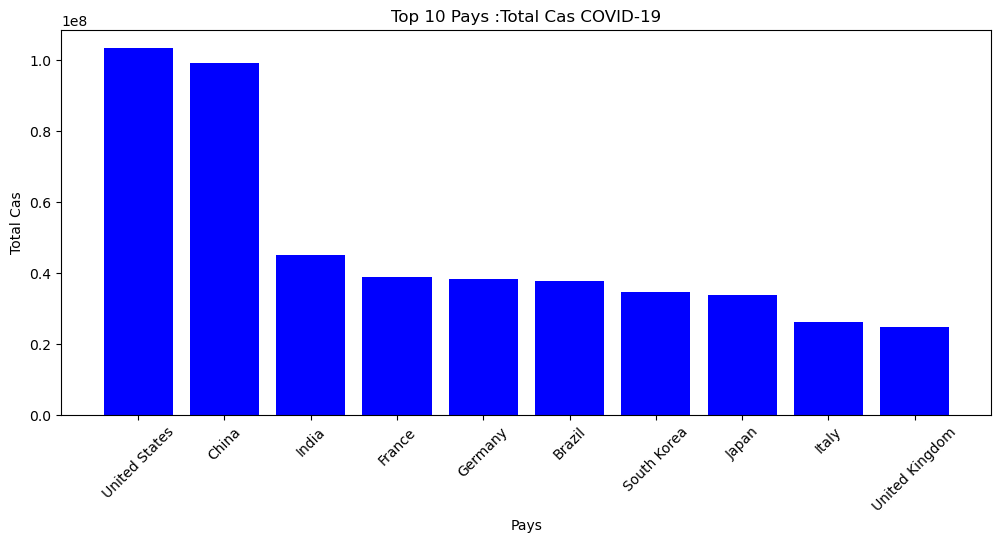

In [10]:
top_cases = df.groupby('location')['total_cases'].max().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 5))
plt.bar(top_cases.index, top_cases.values, color='blue')
plt.title('Top 10 Pays :Total Cas COVID-19')
plt.xlabel('Pays')
plt.ylabel('Total Cas')
plt.xticks(rotation=45)
plt.show()

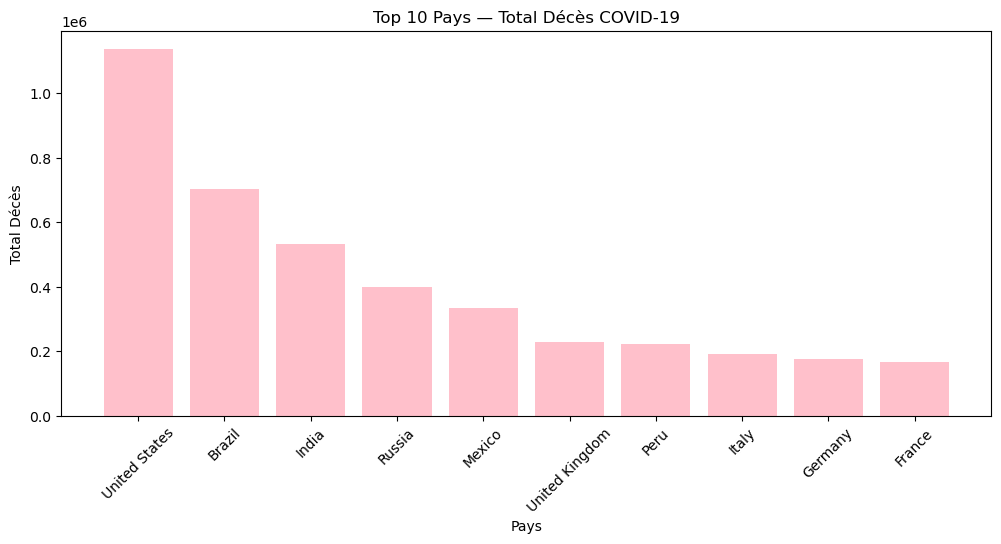

In [11]:
top_deaths = df.groupby('location')['total_deaths'].max().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 5))
plt.bar(top_deaths.index, top_deaths.values, color='pink')
plt.title('Top 10 Pays — Total Décès COVID-19')
plt.xlabel('Pays')
plt.ylabel('Total Décès')
plt.xticks(rotation=45)
plt.show()

In [12]:
a_supprimer = ['World', 'High income', 'Upper middle income', 
               'Lower middle income', 'Low income', 'Europe', 
               'Asia', 'Africa', 'North America', 'South America',
               'Oceania', 'European Union', 'International']

df = df[~df['location'].isin(a_supprimer)]
df = df[df['continent'].notna()]

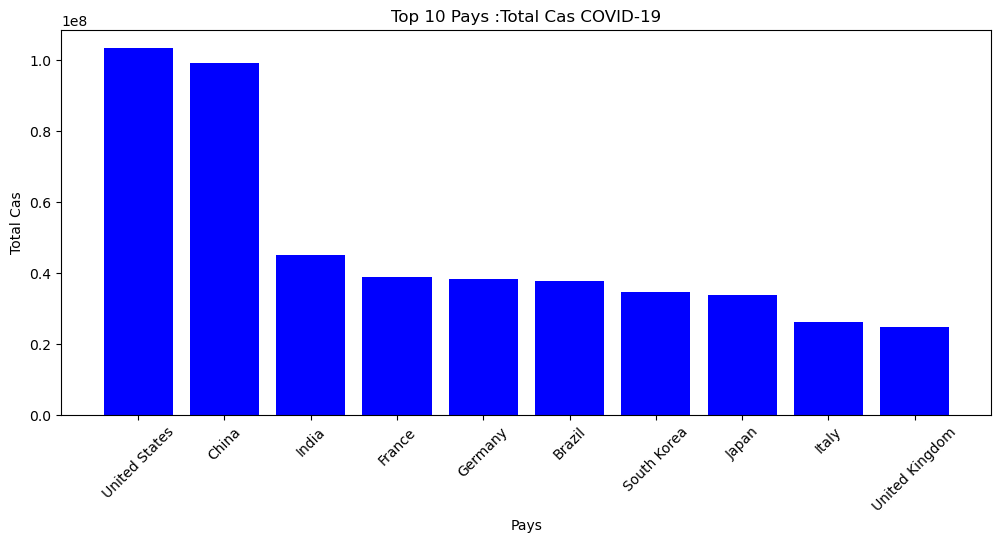

In [30]:
top_cases = df.groupby('location')['total_cases'].max().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 5))
plt.bar(top_cases.index, top_cases.values, color='blue')
plt.title('Top 10 Pays :Total Cas COVID-19')
plt.xlabel('Pays')
plt.ylabel('Total Cas')
plt.xticks(rotation=45)
plt.show()

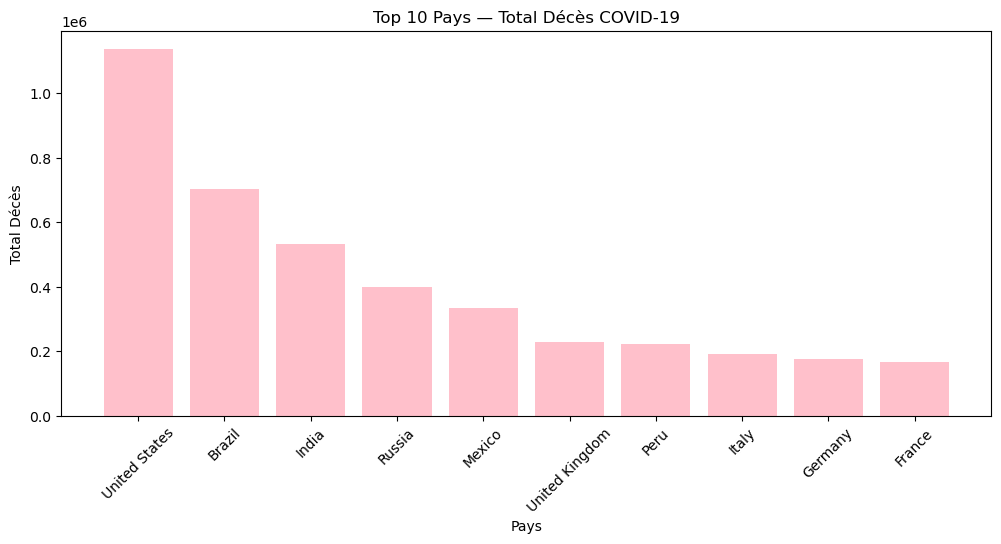

In [31]:
top_deaths = df.groupby('location')['total_deaths'].max().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 5))
plt.bar(top_deaths.index, top_deaths.values, color='pink')
plt.title('Top 10 Pays — Total Décès COVID-19')
plt.xlabel('Pays')
plt.ylabel('Total Décès')
plt.xticks(rotation=45)
plt.show()

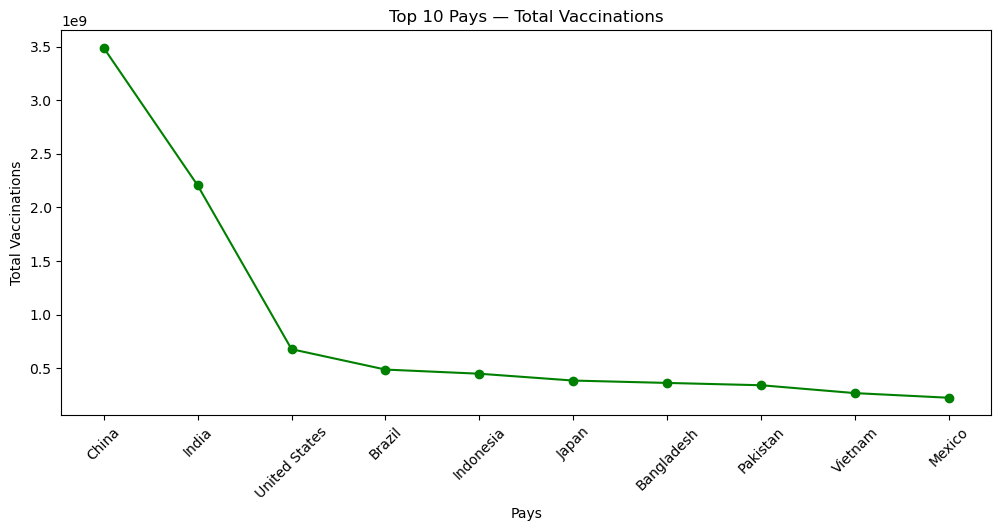

In [32]:
top_vaccinations = df.groupby('location')['total_vaccinations'].max().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 5))
plt.plot(top_vaccinations.index, top_vaccinations.values, color='green',marker='o')
plt.title('Top 10 Pays — Total Vaccinations')
plt.xlabel('Pays')
plt.ylabel('Total Vaccinations')
plt.xticks(rotation=45)
plt.show()

In [33]:
top_vaccinations = df.groupby('location')['total_vaccinations'].max().sort_values(ascending=False).head(10)
print(top_vaccinations)


location
China            3.491077e+09
India            2.206747e+09
United States    6.767288e+08
Brazil           4.864364e+08
Indonesia        4.475958e+08
Japan            3.837477e+08
Bangladesh       3.616746e+08
Pakistan         3.400551e+08
Vietnam          2.664921e+08
Mexico           2.231590e+08
Name: total_vaccinations, dtype: float64


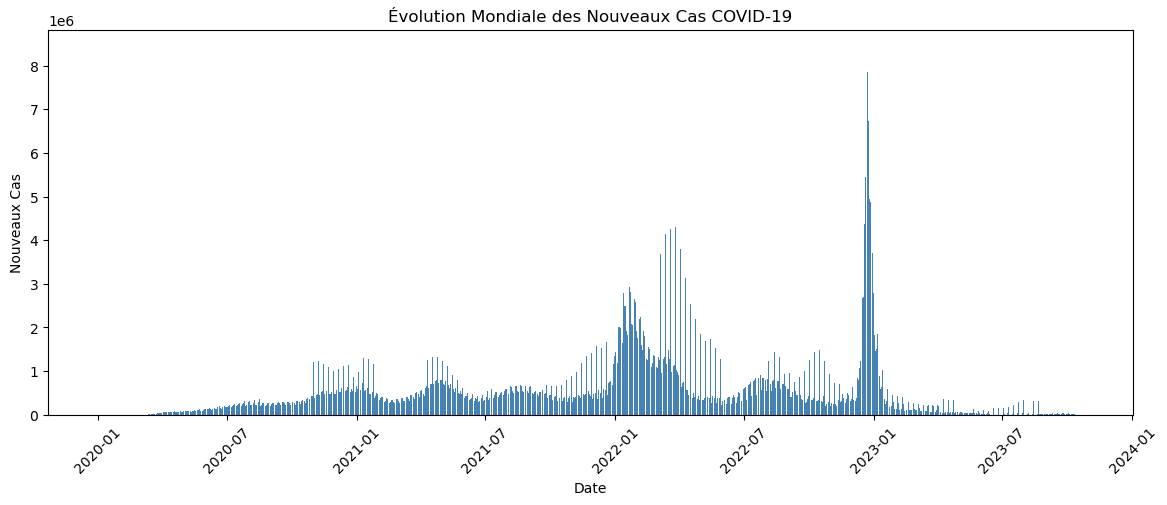

In [37]:
df['date'] = pd.to_datetime(df['date'])
evolution = df.groupby('date')['new_cases'].sum()
plt.figure(figsize=(14, 5))
plt.bar(evolution.index, evolution.values, color='steelblue')
plt.title('Évolution Mondiale des Nouveaux Cas COVID-19')
plt.xlabel('Date')
plt.ylabel('Nouveaux Cas')
plt.xticks(rotation=45)
plt.show()

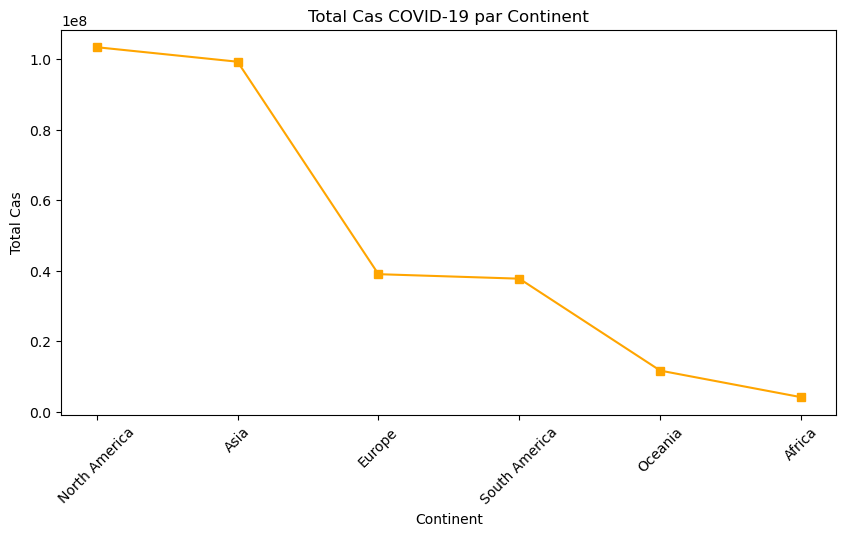

In [42]:
continent = df.groupby('continent')['total_cases'].max().sort_values(ascending=False)
plt.figure(figsize=(10, 5))
plt.plot(continent.index, continent.values, color='orange',marker='s')
plt.title('Total Cas COVID-19 par Continent')
plt.xlabel('Continent')
plt.ylabel('Total Cas')
plt.xticks(rotation=45)
plt.show()